# Assignment 2

Read the file dataset2.csv

The dataset contains missing values as well as outliers.

Choose a method for imputation and apply it

Choose a method for outlier detection and provide the indices of the outliers.


# Importing libraries

In [88]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv('../datasets/dataset2.csv', sep=';', header=None)

df

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.738311,0.669113,0.622368,0.604638,0.686878,0.477681,0.121617,0.978462,0.300009,0.077292,...,0.351451,0.836373,0.254109,0.598209,0.247565,0.673344,0.759184,0.198403,0.017437,0.328162
1,0.398991,0.487942,0.617453,0.672083,0.692769,0.934176,0.190402,0.981219,0.300839,0.146356,...,0.478566,0.732855,0.032738,0.333436,0.137633,0.764767,0.059627,0.378524,0.499575,0.085322
2,0.140433,0.135107,0.228465,0.876200,0.386447,0.656123,0.523236,0.575943,0.081488,0.809256,...,0.338642,0.715689,0.807617,0.086523,0.449743,0.796373,0.569684,0.258360,0.239836,0.469882
3,0.193457,0.236073,0.254791,0.164874,0.920559,0.683868,0.027836,0.724134,0.793451,0.584538,...,0.434057,0.740642,0.897616,0.802401,0.733303,0.527035,0.053701,0.025047,0.824955,0.701065
4,0.077076,0.441993,0.422593,0.766592,0.131284,0.866207,0.847329,0.602439,0.767783,0.683798,...,0.115863,0.882312,0.343852,0.177056,0.649450,0.377550,0.632784,0.421226,0.746538,0.929634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,0.445704,0.415438,0.011887,0.329353,0.130387,0.980425,0.213232,0.835856,0.895957,0.486913,...,0.951909,0.251381,0.935265,0.120924,0.097420,0.507825,0.680404,0.474988,0.097214,0.722691
74,0.241968,0.170564,0.371360,0.745260,0.838933,0.167941,0.516185,0.294448,0.520514,0.138215,...,0.277605,0.383140,0.695454,0.826495,0.646058,0.508483,0.789450,0.983768,0.367226,0.723384
75,0.935079,0.396045,0.262564,0.730501,0.605815,0.062384,0.490049,0.568162,0.502204,0.635892,...,0.149460,0.624562,0.646170,0.566910,0.189663,0.429716,0.893446,0.098203,0.048452,0.663627
76,0.713777,0.806716,0.133408,0.513149,0.309769,0.302984,0.856029,0.320610,0.071119,0.325576,...,0.734686,0.459038,0.396459,0.751803,0.468092,0.100379,0.077075,0.767564,0.798329,0.384088


In [90]:
df.isna().sum().sum()

np.int64(19)

<Axes: >

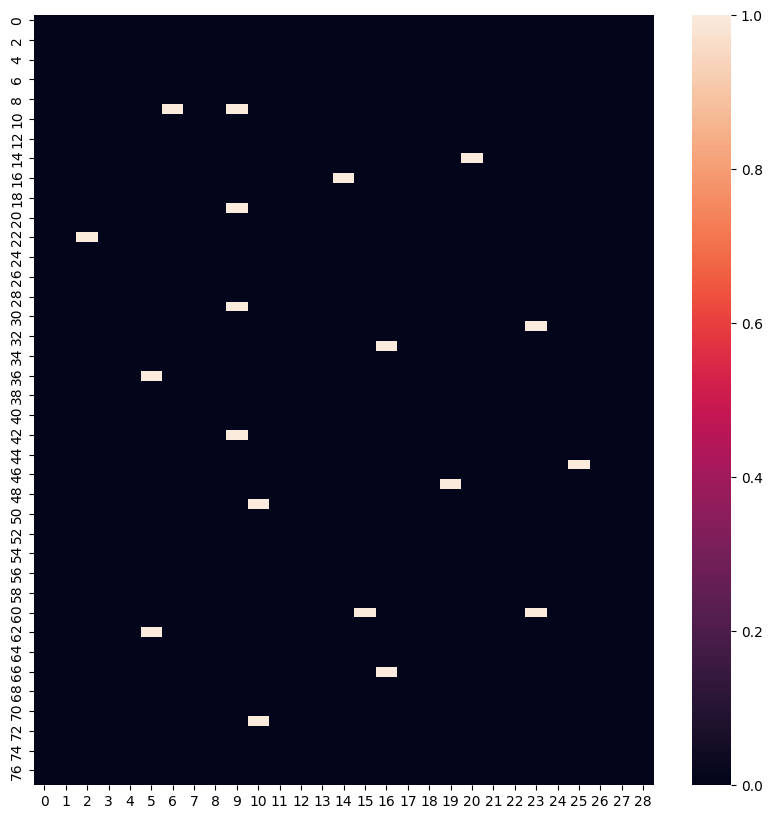

In [91]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.isna())

In [92]:
# Identify numeric columns suitable for normalization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude ID columns and binary columns
exclude_cols = ['Id']  # IDs should never be normalized
binary_cols = [col for col in numeric_cols if df[col].nunique() <= 2]  # Binary (0/1) columns

print("Numeric columns found:")
for col in numeric_cols[:20]:
    print(f"  - {col}: min={df[col].min()}, max={df[col].max()}, range={df[col].max() - df[col].min()}")

# Automatically select columns with large range differences (high variance)
cols_to_normalize = []
for col in numeric_cols:
    if col not in exclude_cols and col not in binary_cols:
        col_range = df[col].max() - df[col].min()
        # Normalize if range > 100 (indicating different scales)
        if col_range > 100:
            cols_to_normalize.append(col)

print(f"\nBinary columns (excluded): {binary_cols}")
print(f"\nColumns selected for normalization (range > 100): {cols_to_normalize}")
print(f"Total: {len(cols_to_normalize)} columns")

Numeric columns found:
  - 0: min=0.009908633, max=0.949285313, range=0.93937668
  - 1: min=0.00252028, max=0.998686378, range=0.996166098
  - 2: min=0.002737977, max=0.988783143, range=0.986045166
  - 3: min=0.014339964, max=0.996594568, range=0.982254604
  - 4: min=0.009738577, max=13.32278578, range=13.313047203
  - 5: min=0.002658823, max=0.999689202, range=0.997030379
  - 6: min=0.011169824, max=0.975491021, range=0.964321197
  - 7: min=0.031755457, max=0.993354551, range=0.961599094
  - 8: min=0.008777014, max=0.998589009, range=0.9898119950000001
  - 9: min=0.036826139, max=0.994625589, range=0.95779945
  - 10: min=0.000984426, max=0.992166172, range=0.991181746
  - 11: min=0.010923297, max=0.984061569, range=0.9731382719999999
  - 12: min=0.003728775, max=0.964297132, range=0.960568357
  - 13: min=0.002675227, max=0.995742811, range=0.993067584
  - 14: min=0.00974134, max=0.999485396, range=0.9897440559999999
  - 15: min=0.004912387, max=0.999584762, range=0.994672375
  - 16: m

In [93]:
# drop missing values
df.dropna()

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.738311,0.669113,0.622368,0.604638,0.686878,0.477681,0.121617,0.978462,0.300009,0.077292,...,0.351451,0.836373,0.254109,0.598209,0.247565,0.673344,0.759184,0.198403,0.017437,0.328162
1,0.398991,0.487942,0.617453,0.672083,0.692769,0.934176,0.190402,0.981219,0.300839,0.146356,...,0.478566,0.732855,0.032738,0.333436,0.137633,0.764767,0.059627,0.378524,0.499575,0.085322
2,0.140433,0.135107,0.228465,0.876200,0.386447,0.656123,0.523236,0.575943,0.081488,0.809256,...,0.338642,0.715689,0.807617,0.086523,0.449743,0.796373,0.569684,0.258360,0.239836,0.469882
3,0.193457,0.236073,0.254791,0.164874,0.920559,0.683868,0.027836,0.724134,0.793451,0.584538,...,0.434057,0.740642,0.897616,0.802401,0.733303,0.527035,0.053701,0.025047,0.824955,0.701065
4,0.077076,0.441993,0.422593,0.766592,0.131284,0.866207,0.847329,0.602439,0.767783,0.683798,...,0.115863,0.882312,0.343852,0.177056,0.649450,0.377550,0.632784,0.421226,0.746538,0.929634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,0.445704,0.415438,0.011887,0.329353,0.130387,0.980425,0.213232,0.835856,0.895957,0.486913,...,0.951909,0.251381,0.935265,0.120924,0.097420,0.507825,0.680404,0.474988,0.097214,0.722691
74,0.241968,0.170564,0.371360,0.745260,0.838933,0.167941,0.516185,0.294448,0.520514,0.138215,...,0.277605,0.383140,0.695454,0.826495,0.646058,0.508483,0.789450,0.983768,0.367226,0.723384
75,0.935079,0.396045,0.262564,0.730501,0.605815,0.062384,0.490049,0.568162,0.502204,0.635892,...,0.149460,0.624562,0.646170,0.566910,0.189663,0.429716,0.893446,0.098203,0.048452,0.663627
76,0.713777,0.806716,0.133408,0.513149,0.309769,0.302984,0.856029,0.320610,0.071119,0.325576,...,0.734686,0.459038,0.396459,0.751803,0.468092,0.100379,0.077075,0.767564,0.798329,0.384088


In [94]:
# mean imputation
df.fillna(df.mean())

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.738311,0.669113,0.622368,0.604638,0.686878,0.477681,0.121617,0.978462,0.300009,0.077292,...,0.351451,0.836373,0.254109,0.598209,0.247565,0.673344,0.759184,0.198403,0.017437,0.328162
1,0.398991,0.487942,0.617453,0.672083,0.692769,0.934176,0.190402,0.981219,0.300839,0.146356,...,0.478566,0.732855,0.032738,0.333436,0.137633,0.764767,0.059627,0.378524,0.499575,0.085322
2,0.140433,0.135107,0.228465,0.876200,0.386447,0.656123,0.523236,0.575943,0.081488,0.809256,...,0.338642,0.715689,0.807617,0.086523,0.449743,0.796373,0.569684,0.258360,0.239836,0.469882
3,0.193457,0.236073,0.254791,0.164874,0.920559,0.683868,0.027836,0.724134,0.793451,0.584538,...,0.434057,0.740642,0.897616,0.802401,0.733303,0.527035,0.053701,0.025047,0.824955,0.701065
4,0.077076,0.441993,0.422593,0.766592,0.131284,0.866207,0.847329,0.602439,0.767783,0.683798,...,0.115863,0.882312,0.343852,0.177056,0.649450,0.377550,0.632784,0.421226,0.746538,0.929634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,0.445704,0.415438,0.011887,0.329353,0.130387,0.980425,0.213232,0.835856,0.895957,0.486913,...,0.951909,0.251381,0.935265,0.120924,0.097420,0.507825,0.680404,0.474988,0.097214,0.722691
74,0.241968,0.170564,0.371360,0.745260,0.838933,0.167941,0.516185,0.294448,0.520514,0.138215,...,0.277605,0.383140,0.695454,0.826495,0.646058,0.508483,0.789450,0.983768,0.367226,0.723384
75,0.935079,0.396045,0.262564,0.730501,0.605815,0.062384,0.490049,0.568162,0.502204,0.635892,...,0.149460,0.624562,0.646170,0.566910,0.189663,0.429716,0.893446,0.098203,0.048452,0.663627
76,0.713777,0.806716,0.133408,0.513149,0.309769,0.302984,0.856029,0.320610,0.071119,0.325576,...,0.734686,0.459038,0.396459,0.751803,0.468092,0.100379,0.077075,0.767564,0.798329,0.384088


In [95]:
from sklearn.impute import KNNImputer

df_imputed = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(df))

df_imputed

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,0.738311,0.669113,0.622368,0.604638,0.686878,0.477681,0.121617,0.978462,0.300009,0.077292,...,0.351451,0.836373,0.254109,0.598209,0.247565,0.673344,0.759184,0.198403,0.017437,0.328162
1,0.398991,0.487942,0.617453,0.672083,0.692769,0.934176,0.190402,0.981219,0.300839,0.146356,...,0.478566,0.732855,0.032738,0.333436,0.137633,0.764767,0.059627,0.378524,0.499575,0.085322
2,0.140433,0.135107,0.228465,0.876200,0.386447,0.656123,0.523236,0.575943,0.081488,0.809256,...,0.338642,0.715689,0.807617,0.086523,0.449743,0.796373,0.569684,0.258360,0.239836,0.469882
3,0.193457,0.236073,0.254791,0.164874,0.920559,0.683868,0.027836,0.724134,0.793451,0.584538,...,0.434057,0.740642,0.897616,0.802401,0.733303,0.527035,0.053701,0.025047,0.824955,0.701065
4,0.077076,0.441993,0.422593,0.766592,0.131284,0.866207,0.847329,0.602439,0.767783,0.683798,...,0.115863,0.882312,0.343852,0.177056,0.649450,0.377550,0.632784,0.421226,0.746538,0.929634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,0.445704,0.415438,0.011887,0.329353,0.130387,0.980425,0.213232,0.835856,0.895957,0.486913,...,0.951909,0.251381,0.935265,0.120924,0.097420,0.507825,0.680404,0.474988,0.097214,0.722691
74,0.241968,0.170564,0.371360,0.745260,0.838933,0.167941,0.516185,0.294448,0.520514,0.138215,...,0.277605,0.383140,0.695454,0.826495,0.646058,0.508483,0.789450,0.983768,0.367226,0.723384
75,0.935079,0.396045,0.262564,0.730501,0.605815,0.062384,0.490049,0.568162,0.502204,0.635892,...,0.149460,0.624562,0.646170,0.566910,0.189663,0.429716,0.893446,0.098203,0.048452,0.663627
76,0.713777,0.806716,0.133408,0.513149,0.309769,0.302984,0.856029,0.320610,0.071119,0.325576,...,0.734686,0.459038,0.396459,0.751803,0.468092,0.100379,0.077075,0.767564,0.798329,0.384088


In [98]:
# Function to detect outliers using IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

# Detect outliers (apply to imputed data, not original df with missing values)
outliers = detect_outliers_iqr(df_imputed)

# Get row indices where ANY column has an outlier
outlier_rows = outliers.any(axis=1)
outlier_indices = df_imputed[outlier_rows].index.tolist()

print(f"Number of rows with outliers: {sum(outlier_rows)}")
print(f"Outlier row indices: {outlier_indices[:20]}")  # Show first 20

# Show the actual outlier data
print("\nOutlier rows:")
df_imputed[outlier_rows].head(10)

Number of rows with outliers: 5
Outlier row indices: [6, 17, 27, 34, 49]

Outlier rows:


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
6,0.710359,0.220098,0.394982,0.172325,13.322786,0.540872,0.171719,0.755122,0.720348,0.775355,...,0.561078,0.730243,0.113426,0.681003,0.144904,0.464677,0.332298,0.895689,0.659706,0.353677
17,0.949285,0.644572,0.695829,0.794783,0.580090,0.318284,0.458891,0.365778,0.386149,0.415700,...,0.845444,0.419901,0.366127,0.499604,0.554316,-0.737657,0.998379,0.003392,0.794229,0.122465
27,0.462182,0.378721,0.978203,0.610612,0.696096,0.955927,0.718365,0.893450,0.833330,0.039568,...,0.945724,42.484873,0.958407,0.401731,0.029187,0.442877,0.870031,0.069770,0.399508,0.073594
34,0.517495,0.548972,0.549997,0.861710,0.023557,0.270504,0.327016,0.819949,0.970815,0.688389,...,0.167555,0.122453,0.865983,0.138175,0.525498,0.067913,0.129780,0.331156,0.775487,0.134301
49,0.554920,0.734705,0.603224,0.766910,2.506299,0.609314,0.636482,0.396342,0.293435,0.807117,...,0.800450,0.393704,0.344258,0.843589,0.229297,0.278760,0.032458,0.002541,0.150099,0.666481


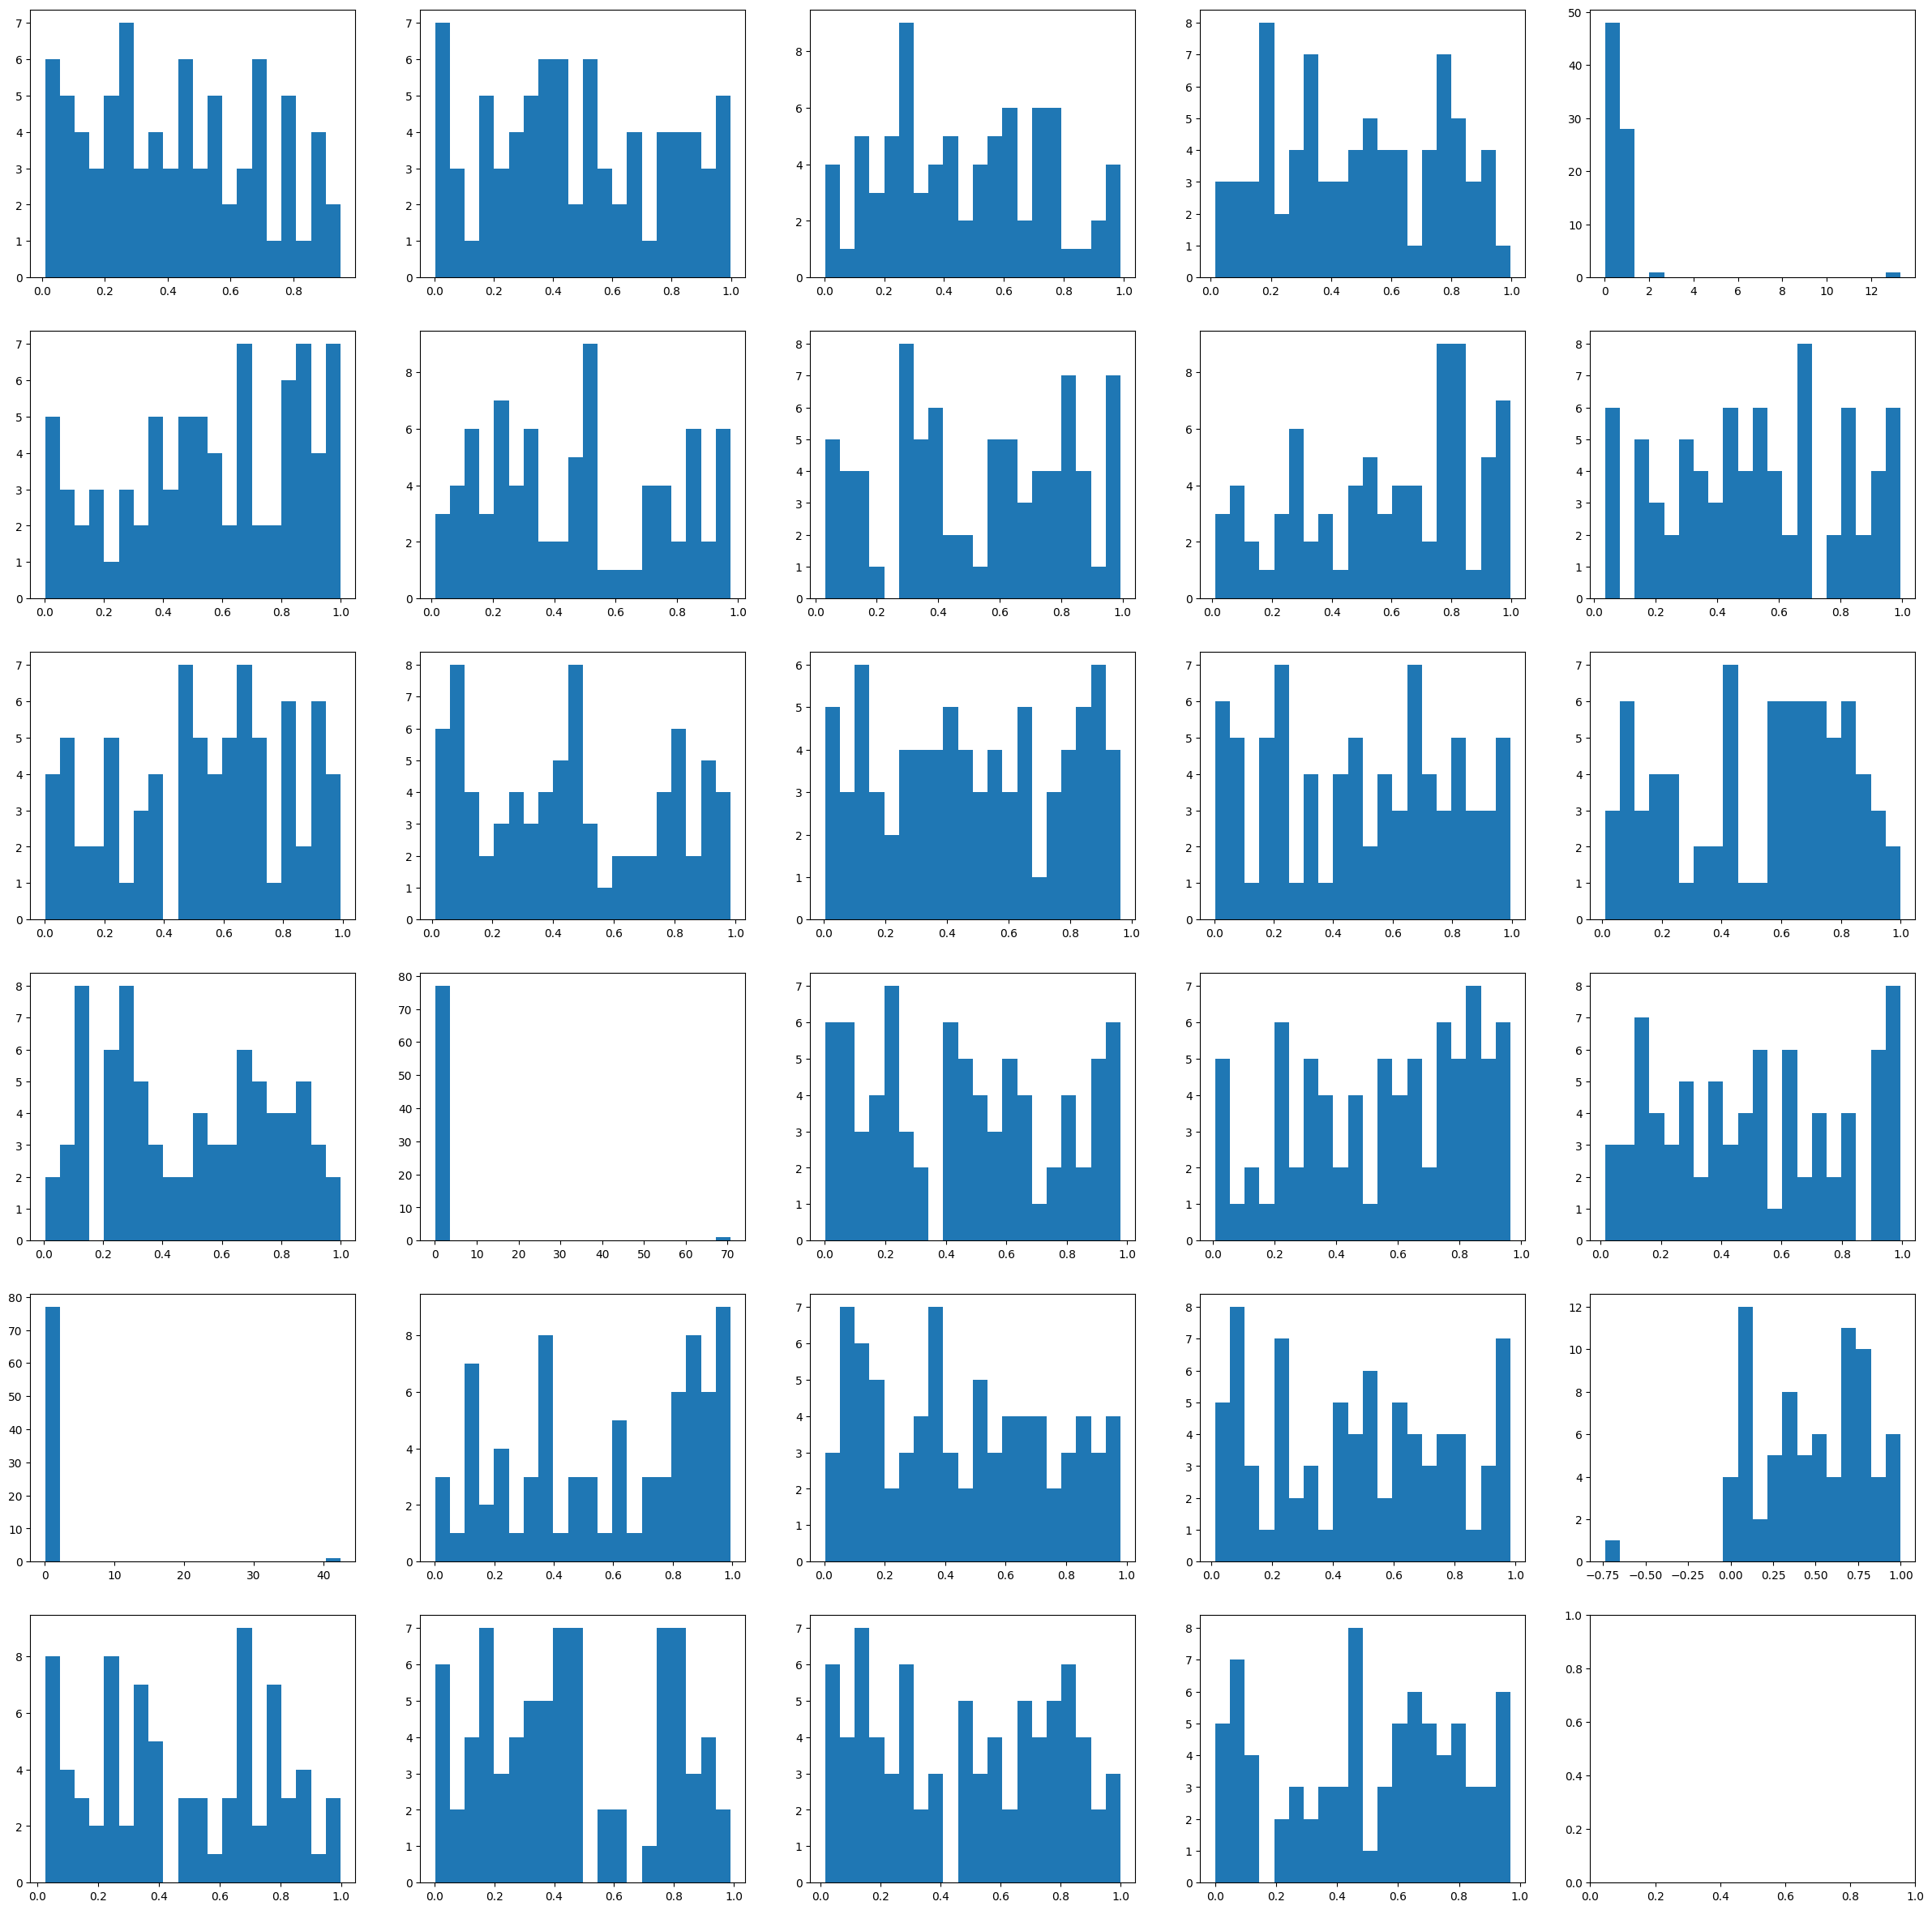

In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(30, 30))
axes = axes.flatten()

for ax, col in zip(axes, df_imputed.columns):
    
    col_df = df_imputed[col]

    ax.hist(col_df, bins=20)

plt.show()